# Fine-tune Lost & Found Models (LlamaIndex + CLIP)

This notebook fine-tunes the two open-source models used by the Campus Lost & Found AI module:

| Task | Base model | Fine-tune tool |
|------|------------|----------------|
| NLP / text matching | `all-MiniLM-L6-v2` | **LlamaIndex** `SentenceTransformersFinetuneEngine` |
| Image recognition | `clip-ViT-B-32` | sentence-transformers contrastive training (LlamaIndex has no CLIP image finetune engine) |

Outputs are saved to:
- `ai-module/models/finetuned-minilm/`
- `ai-module/models/finetuned-clip/`

The FastAPI service loads these folders automatically when present.

## 1. Setup

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

# Resolve ai-module root whether the notebook lives in notebooks/ or is run from scripts
CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / "src").exists() else CWD.parent
sys.path.insert(0, str(ROOT))

DATA = ROOT / "data" / "finetune"
IMG_DIR = DATA / "images"
MINILM_OUT = ROOT / "models" / "finetuned-minilm"
CLIP_OUT = ROOT / "models" / "finetuned-clip"

DATA.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)

ROOT: /Users/pranavd/Desktop/waste/JARVIS-Lost-and-Found/ai-module


## 2. Build synthetic campus lost/found text pairs

LlamaIndex expects an `EmbeddingQAFinetuneDataset`: queries, corpus documents, and `relevant_docs` mappings.

In [2]:
PAIRS = [
    ("Lost black Nike backpack with laptop sleeve near Central Library",
     "Found dark Nike bag for laptop by the campus library entrance"),
    ("Misplaced navy blue Hydro Flask water bottle in Engineering block",
     "Found dark blue metal flask outside Engineering building"),
    ("Lost silver MacBook Pro 14-inch with sticker of a cat",
     "Found grey Apple laptop with cat sticker in lecture hall"),
    ("Missing red student ID card near cafeteria",
     "Picked up crimson campus ID badge by the food court"),
    ("Lost leather wallet with university logo at sports complex",
     "Found brown wallet with campus crest in gym lobby"),
    ("Cannot find black Sony WH-1000XM headphones in dorm laundry",
     "Found over-ear Sony noise cancelling headphones in laundry room"),
    ("Lost set of room keys with blue keychain at parking lot B",
     "Found keys on blue fob near Parking Lot B"),
    ("Misplaced green umbrella in Chemistry lab",
     "Found lime green umbrella outside Chemistry department"),
    ("Lost Apple AirPods case with initials PD engraved",
     "Found white AirPods charging case engraved PD"),
    ("Missing calculus textbook by Stewart near study hall",
     "Found Stewart Calculus book in the study lounge"),
    ("Lost grey North Face jacket in auditorium",
     "Found gray outdoor jacket (North Face) in main auditorium"),
    ("Misplaced pink iPhone 13 with cracked screen protector",
     "Found damaged-screen pink iPhone near bus stop"),
    ("Lost bicycle helmet matt black at bike rack",
     "Found matte black bike helmet by the bike stands"),
    ("Missing USB-C charger brick 65W in computer lab",
     "Found 65 watt USB-C power adapter in CS lab"),
    ("Lost brown leather belt in locker room",
     "Found tan leather belt in the locker area"),
    ("Misplaced transparent geometry box in math tutorial",
     "Found clear geometry set after math class"),
    ("Lost black Dell laptop bag with shoulder strap",
     "Found Dell branded laptop messenger bag"),
    ("Missing prescription glasses with round gold frames",
     "Found round gold-rimmed eyeglasses in cafe"),
    ("Lost red scarf near winter bus shelter",
     "Found crimson scarf at the bus shelter"),
    ("Misplaced scientific calculator Casio fx-991 in exam hall",
     "Found Casio fx-991 calculator after exams"),
]

queries, corpus, relevant = {}, {}, {}
for i, (lost, found) in enumerate(PAIRS):
    queries[f"q{i}"] = lost
    corpus[f"d{i}"] = found
    relevant[f"q{i}"] = [f"d{i}"]
    queries[f"qr{i}"] = found
    corpus[f"dr{i}"] = lost
    relevant[f"qr{i}"] = [f"dr{i}"]

text_dataset = {"queries": queries, "corpus": corpus, "relevant_docs": relevant, "mode": "text"}
(DATA / "text_qa_dataset.json").write_text(json.dumps(text_dataset, indent=2))
print(f"Saved {len(queries)} text queries -> {DATA / 'text_qa_dataset.json'}")

Saved 40 text queries -> /Users/pranavd/Desktop/waste/JARVIS-Lost-and-Found/ai-module/data/finetune/text_qa_dataset.json


## 3. Fine-tune MiniLM with LlamaIndex

In [3]:
from src.finetune_utils import load_llamaindex_finetune_engine
from sentence_transformers import SentenceTransformer as ST

SentenceTransformersFinetuneEngine, EmbeddingQAFinetuneDataset = load_llamaindex_finetune_engine()

if (MINILM_OUT / 'modules.json').exists():
    print('MiniLM already fine-tuned at', MINILM_OUT)
    minilm = ST(str(MINILM_OUT))
else:
    q_ids = list(text_dataset['queries'].keys())
    split = max(2, len(q_ids) // 5)
    val_ids = set(q_ids[:split])

    train_raw = {
        'queries': {k: v for k, v in text_dataset['queries'].items() if k not in val_ids},
        'corpus': text_dataset['corpus'],
        'relevant_docs': {k: v for k, v in text_dataset['relevant_docs'].items() if k not in val_ids},
        'mode': 'text',
    }
    val_raw = {
        'queries': {k: v for k, v in text_dataset['queries'].items() if k in val_ids},
        'corpus': text_dataset['corpus'],
        'relevant_docs': {k: v for k, v in text_dataset['relevant_docs'].items() if k in val_ids},
        'mode': 'text',
    }

    train_ds = EmbeddingQAFinetuneDataset(**train_raw)
    val_ds = EmbeddingQAFinetuneDataset(**val_raw)

    engine = SentenceTransformersFinetuneEngine(
        dataset=train_ds,
        model_id='sentence-transformers/all-MiniLM-L6-v2',
        model_output_path=str(MINILM_OUT),
        batch_size=8,
        val_dataset=val_ds,
        epochs=2,
        show_progress_bar=True,
        evaluation_steps=20,
    )

    print('Fine-tuning MiniLM via LlamaIndex...')
    engine.finetune()
    minilm = ST(str(MINILM_OUT))
    print('Saved MiniLM ->', MINILM_OUT)


MiniLM already fine-tuned at /Users/pranavd/Desktop/waste/JARVIS-Lost-and-Found/ai-module/models/finetuned-minilm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [4]:
# Quick NLP sanity check
a = "Black Nike backpack with laptop sleeve"
b = "Dark Nike bag for laptop"
c = "Red student ID card"
ea, eb, ec = minilm.encode([a, b, c], normalize_embeddings=True)
print("similar pair:", float(ea @ eb))
print("different pair:", float(ea @ ec))

similar pair: 0.806325376033783
different pair: 0.23360073566436768


## 4. Build synthetic image–text pairs for CLIP

LlamaIndex's embedding finetune engine is **text-only**. For CLIP we use the same underlying `sentence-transformers` contrastive training API on campus-style image/caption pairs.

Saved 72 image-text pairs


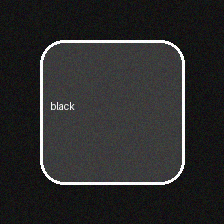

In [5]:
COLORS = {
    "black backpack": ((20, 20, 20), (60, 60, 60)),
    "navy water bottle": ((20, 40, 100), (40, 70, 150)),
    "silver laptop": ((180, 180, 185), (210, 210, 215)),
    "red ID card": ((180, 30, 40), (220, 60, 70)),
    "brown wallet": ((110, 70, 40), (140, 95, 55)),
    "black headphones": ((15, 15, 15), (45, 45, 45)),
    "blue keys": ((30, 90, 180), (70, 130, 220)),
    "green umbrella": ((30, 140, 60), (60, 180, 90)),
    "white earbuds": ((235, 235, 235), (250, 250, 250)),
    "textbook": ((90, 50, 30), (130, 80, 50)),
    "grey jacket": ((100, 100, 105), (140, 140, 145)),
    "pink phone": ((220, 120, 160), (240, 160, 190)),
}

def make_item_image(name, colors, seed, path):
    rng = np.random.default_rng(seed)
    img = Image.new("RGB", (224, 224), colors[0])
    draw = ImageDraw.Draw(img)
    draw.rounded_rectangle((40, 40, 184, 184), radius=24, fill=colors[1], outline=(255, 255, 255), width=3)
    noise = rng.integers(0, 25, (224, 224, 3), dtype=np.uint8)
    base = np.asarray(img, dtype=np.int16)
    img = Image.fromarray(np.clip(base + noise - 12, 0, 255).astype(np.uint8))
    draw = ImageDraw.Draw(img)
    draw.text((50, 100), name.split()[0][:10], fill=(255, 255, 255))
    img.save(path)

clip_pairs = []
for i, (name, colors) in enumerate(COLORS.items()):
    lost_path = IMG_DIR / f"{i:02d}_lost.png"
    found_path = IMG_DIR / f"{i:02d}_found.png"
    make_item_image(name, colors, 100 + i, lost_path)
    make_item_image(name, colors, 200 + i, found_path)
    for cap in [
        f"a photo of a {name}",
        f"campus lost and found item: {name}",
        f"found {name} on campus",
    ]:
        clip_pairs.append({"image": str(lost_path.relative_to(ROOT)), "text": cap})
        clip_pairs.append({"image": str(found_path.relative_to(ROOT)), "text": cap})

(DATA / "clip_image_text_pairs.json").write_text(json.dumps(clip_pairs, indent=2))
print(f"Saved {len(clip_pairs)} image-text pairs")
Image.open(IMG_DIR / "00_lost.png")

## 5. Fine-tune CLIP

In [6]:
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses

if (CLIP_OUT / 'modules.json').exists():
    print('CLIP already fine-tuned at', CLIP_OUT)
    clip = SentenceTransformer(str(CLIP_OUT))
else:
    clip = SentenceTransformer('clip-ViT-B-32')
    examples = [
        InputExample(texts=[Image.open(ROOT / p['image']).convert('RGB'), p['text']])
        for p in clip_pairs
    ]
    loader = DataLoader(examples, shuffle=True, batch_size=4)
    loss = losses.MultipleNegativesRankingLoss(clip)

    print('Fine-tuning CLIP...')
    clip.fit(
        train_objectives=[(loader, loss)],
        epochs=1,
        warmup_steps=5,
        show_progress_bar=True,
        output_path=str(CLIP_OUT),
    )
    clip.save(str(CLIP_OUT))
    print('Saved CLIP ->', CLIP_OUT)


CLIP already fine-tuned at /Users/pranavd/Desktop/waste/JARVIS-Lost-and-Found/ai-module/models/finetuned-clip


/var/folders/kq/jmkbpf_d78321w1g49py7dtm0000gn/T/ipykernel_47203/1823192255.py:2: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [7]:
# Visual similarity sanity check
img_a = Image.open(IMG_DIR / "00_lost.png").convert("RGB")
img_b = Image.open(IMG_DIR / "00_found.png").convert("RGB")
img_c = Image.open(IMG_DIR / "03_lost.png").convert("RGB")  # red ID card

ea = clip.encode(img_a, normalize_embeddings=True)
eb = clip.encode(img_b, normalize_embeddings=True)
ec = clip.encode(img_c, normalize_embeddings=True)
print("same-item images:", float(ea @ eb))
print("different-item images:", float(ea @ ec))

same-item images: 0.9988267421722412
different-item images: 0.3120553195476532


## 6. Verify project loaders pick up fine-tuned weights

In [8]:
import importlib
import src.feature_extraction as fe
import src.text_matcher as tm

importlib.reload(fe)
importlib.reload(tm)

print("IMAGE:", fe.feature_extractor.model_info)
print("TEXT:", tm.text_matcher.model_info)
assert "finetuned" in fe.feature_extractor.model_name or fe.feature_extractor.backend == "clip"
assert "finetuned" in tm.text_matcher.model_name or tm.text_matcher.backend == "sentence-transformers"
print("Loaders OK")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[ImageFeatureExtractor] Loaded finetuned-clip (clip-ViT-B-32) (dim=512)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[TextMatcher] Loaded finetuned-minilm (all-MiniLM-L6-v2 / LlamaIndex) (dim=384)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

[ImageFeatureExtractor] Loaded finetuned-clip (clip-ViT-B-32) (dim=512)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[TextMatcher] Loaded finetuned-minilm (all-MiniLM-L6-v2 / LlamaIndex) (dim=384)
IMAGE: {'name': 'finetuned-clip (clip-ViT-B-32)', 'type': 'vision-language', 'family': 'CLIP (open-source / fine-tuned)', 'architecture': 'ViT-B/32', 'backend': 'clip', 'embedding_dim': 512, 'finetuned': True, 'task': 'image recognition / visual similarity embeddings'}
TEXT: {'name': 'finetuned-minilm (all-MiniLM-L6-v2 / LlamaIndex)', 'type': 'sentence-embedding', 'family': 'MiniLM / BERT (Hugging Face)', 'architecture': 'all-MiniLM-L6-v2', 'backend': 'sentence-transformers', 'embedding_dim': 384, 'finetuned': True, 'task': 'NLP semantic similarity for title, description, category, location'}
Loaders OK


### Notes
- This run uses **synthetic** campus pairs for a lightweight demo fine-tune (1–2 epochs).
- For production quality, replace the synthetic data with real lost/found reports and photos, then re-run.
- `llama-index-finetuning` is deprecated upstream; this project loads `SentenceTransformersFinetuneEngine` via `src/finetune_utils.py` to avoid a broken `mistralai` import side-effect.